In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from scipy.integrate import solve_ivp

In [238]:
M = 1
a = 0

In [239]:
def v_prime(t,y,a=a):
    r = np.array([y[0],y[1],y[2]])
    v = np.array([y[3],y[4],y[5]])
    x,y,z = r[0],r[1],r[2]
    v4 = np.insert(v,0,1)
    
    K = (x**2+y**2+z**2-a**2)/2
    
    W = np.sqrt(K**2+a**2*z**2)
    
    rkw = np.sqrt(K+W)
    
    dx_K = x
    dy_K = y
    dz_K = z
    di_K = np.array([dx_K, dy_K, dz_K])
    


    dx_W = K*x/W
    dy_W = K*y/W
    dz_W = z*(K+a**2)/W
    di_W = np.array([dx_W , dy_W , dz_W ])
    rho2 = rkw **2+a**2
    
    dx_r = x*rkw /(2*W )
    dy_r  = y*rkw /(2*W )
    dz_r  = z*rho2 /(2*rkw *W )
    di_r = np.array([dx_r , dy_r , dz_r ])

    dx_S  = 2*x*rkw **4/(W )
    dy_S  = 2*y*rkw **4/(W )
    dz_S  = 2*x*rkw **2*rho2 **2/(W )+2*a**2*z
    di_S = np.array([dx_S , dy_S , dz_S ])

    f  = M*rkw /W 
    
    dx_f  = M/W  * (dx_r -rkw /W *dx_W )
    dy_f  = M/W  * (dy_r -rkw /W *dy_W )
    dz_f  = M/W  * (dz_r -rkw /W *dz_W )
    di_f = np.array([dx_f , dy_f , dz_f ])

    Lx = (x*(a**2-rkw **2) - 2*a*rkw *y)/(rho2 **2)
    Ly = (y*(a**2-rkw **2) - 2*a*rkw *x)/(rho2 **2)
    Lz = -z/rkw **2
    L = np.array([Lx , Ly , Lz ])


    '''indici bassi'''
    lt = 1
    lx = (rkw *x+a*y)/rho2 
    ly = (rkw *y-a*x)/rho2 
    lz = z/rkw 
    l = np.array([lt, lx, ly, lz])

    dx_lx = rkw /rho2  + Lx *dx_r 
    dy_lx = a/rho2  + Lx *dy_r 
    dz_lx = Lx *dz_r 
    di_lx = np.array([dx_lx, dy_lx, dz_lx])

    dy_ly = rkw /rho2  + Ly *dy_r 
    dx_ly = -a/rho2  + Ly *dx_r 
    dz_ly = Ly *dz_r 
    di_ly = np.array([dx_ly, dy_ly, dz_ly])

    dx_lz = Lz *dx_r 
    dy_lz = Lz *dy_r 
    dz_lz = 1/rkw +Lz *dz_r 
    di_lz = np.array([dx_lz, dy_lz, dz_lz])

    di_lt = np.array([0,0,0])
    Dl =  np.array([di_lt, di_lx , di_ly , di_lz ])
    Dl = Dl.T
    deriv_l = Dl


    D_g = np.zeros((4,4,4))
    for k in range(3):
        for mu in range(4):
            for nu in range(4):
                D_g[k+1, mu, nu] = di_f [k] * l [mu] * l [nu] + f  * deriv_l [k,mu] * l [nu] + f  * l [mu] * deriv_l [k,nu]
                D_g[0, mu, nu] = 0

    deriv_gmn444 = D_g

    ll = l 
    ll[0] = -ll[0]
    dg = deriv_gmn444 

    G = np.einsum('i, jki -> jk',  ll, dg) + np.einsum('i, kji -> jk',  ll, dg) - np.einsum('i, ijk -> jk',  ll, dg) 
    

    eta = np.zeros((4,4))
    eta[0,0] = -1
    for i in range(1,4):
        eta[i,i] = 1
    eta_mn = eta

    B = np.zeros((4,4,4))
    for alpha in range(4):
        for beta in range(4):
            for sigma in range(4):
                B[alpha,beta,sigma] = deriv_gmn444 [alpha,beta,sigma] + deriv_gmn444 [beta,alpha,sigma] - deriv_gmn444 [sigma,alpha,beta]
    B_abs = B

    n = eta_mn  
    B_2 =  0.5 * B_abs 
    gamma = np.einsum('ms, abs -> mab', n, B_2)
    Gamma_bar_mab = gamma   

    Gs = np.einsum('ab,a,b -> ', G , v4, v4)
    G_scalar = Gs

    
    
    gmu_vv = np.einsum('mab, a, b -> m', Gamma_bar_mab , v4, v4)
    gi_vv = gmu_vv[1:]
    gmu_vvv = np.einsum('mab, a, b, n -> mn', Gamma_bar_mab , v4, v4, v4)
    gt_vvvi = gmu_vvv[0,1:]
    Fi = -gi_vv + gt_vvvi
    
    dvdt = Fi + f *0.5 * G_scalar * (l [1:] + v4[1:])
    y = np.append(v , dvdt)
    return y

In [240]:
x = np.array([1,2,3])
v = np.array([1,2,3])
y = np.append(x,v)
v_prime(0,y)


array([ 1.        ,  2.        ,  3.        ,  3.87053216,  7.74106433,
       11.61159649])

In [241]:
h = 0.01
tf = 250000

t_span =  [0,tf]

y0 = [50, 0, 0, 0, 0.14142136, 0]

t_ev = np.linspace(0,250000,int(1e4))

sol = solve_ivp(v_prime, t_span, y0, t_eval=t_ev, rtol=1e-10, atol=1e-10)

In [242]:
(sol['t']).shape, (sol['y'][0]).shape

((10000,), (10000,))

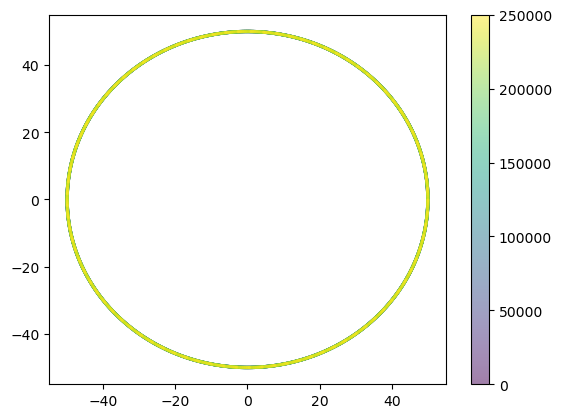

In [243]:
color = sol['t']
plt.scatter(sol['y'][0], sol['y'][1],c=color,s=2,alpha=0.5)
plt.colorbar()

In [383]:
e = 0.9
a = 0.
sma = 50
p = sma * (1-e**2)


rapo = p/(1-e)
rperi = p/(1+e)

In [384]:
# Q = Lx**2 + Ly**2

In [385]:
def E(p=p,e=e):
    return np.sqrt((p-2-2*e)*(p-2+2*e)/(p*(p-3-e**2)))
def L_z(p=p,e=e):
    return p/np.sqrt(p-3-e**2)
def Q(L_x,L_y,p=p,e=e):
    return L_x**2 + L_y**2

Q = Q(0,0)
Q

0

In [386]:
def rtp_prime(t,y,args=None):
    #a, M, p, e = args
    t,r,theta,phi = y[0],y[1],y[2],y[3]
    #u = np.array([y[3],y[4],y[5]])
    
    E = np.sqrt((p-2-2*e)*(p-2+2*e)/(p*(p-3-e**2)))
    #print(E)
    Lz = p/np.sqrt(p-3-e**2)
    #print(Lz)
    
    Delta = r**2-2*M*r+a**2
    #print(Delta)
    Sigma = r**2+a*2*np.cos(theta)**2
    #print(Sigma)

    R = (E*(r**2+a**2)-a*Lz)**2 - Delta*(r**2+(Lz-a*E)**2+Q)
    if R<1e-17: R = 0
    Theta = Q - np.cos(theta)**2*(a**2*(1-E**2)+Lz**2/np.sin(theta)**2)
    if abs(np.cos(theta))<1e-16: Theta = 0
    #print(Theta)


    
    t_prime = ((r**2+a**2)*(E*(r**2+a**2)-a*Lz)/Delta - a*(a*E*np.sin(theta)**2-Lz)) / Sigma
    #print(t_prime)

    phi_prime = (a*(E*(r**2+a**2)-a*Lz)/Delta - (a*E-Lz/np.sin(theta)**2)) / Sigma
    #print(phi_prime)

    r_prime = np.sqrt(R)/Sigma
    if (r==rapo or r==rperi): r_prime=0
    #print(r_prime)

    theta_prime = np.sqrt(Theta)/Sigma
    #print(theta_prime)

    
    return np.array([t,r,theta,phi, t_prime,r_prime,theta_prime,phi_prime])

In [387]:
y0 = rtp_prime(0,[0,rapo, np.pi/2, 0, 1, 0, 0, 1e3])
y0

array([0.00000000e+00, 9.50000000e+01, 1.57079633e+00, 0.00000000e+00,
       1.01158323e+00, 0.00000000e+00, 0.00000000e+00, 4.41286114e-04])

In [388]:
# h = 0.01
# tf = 25000

# t_span =  [0,tf]


# t_ev = np.linspace(0,25000,int(1e4))

# sol = solve_ivp(rtp_prime, t_span, y0, t_eval=t_ev, rtol=1e-10, atol=1e-10)

In [389]:
v_BL = y0[4:]/y0[4]
v_BL

array([1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.36233123e-04])

In [390]:
y0_BL = np.append(y0[:4],v_BL)

t_BL,r_BL,theta_BL,phi_BL = y0[:4]
y0_BL

array([0.00000000e+00, 9.50000000e+01, 1.57079633e+00, 0.00000000e+00,
       1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.36233123e-04])

In [398]:
x = np.sqrt(r_BL**2+a**2)*np.sin(theta_BL)*np.cos(phi_BL)
y = np.sqrt(r_BL**2+a**2)*np.sin(theta_BL)*np.sin(phi_BL)
z = r_BL*np.cos(theta_BL)
X_KS = np.array([x,y,z])

Delta = r_BL**2-2*M*r_BL+a**2
phi_ = phi_BL + np.arctan(a/r_BL)
rho = np.sqrt(r_BL**2+a**2)

dxdr = (r_BL*np.cos(phi_) + a*np.sin(phi_)) * np.sin(theta_BL) / rho
dydr = (r_BL*np.sin(phi_) - a*np.cos(phi_)) * np.sin(theta_BL) / rho  
dzdr = np.cos(theta_BL)

dxdtheta = rho * np.cos(theta_BL) * np.cos(phi_)
dydtheta = rho * np.cos(theta_BL) * np.sin(phi_)
dzdtheta = -r_BL * np.sin(theta_BL)

dxdphi = -rho * np.sin(theta_BL) * np.sin(phi_)
dydphi = rho * np.sin(theta_BL) * np.cos(phi_)
dzdphi = 0.0

J = np.array( [[1, 2*M*r_BL/Delta, 0, 0],
              [0, dxdr, dxdtheta, dxdphi],
              [0, dydr, dydtheta, dydphi],
              [0, dzdr, dzdtheta, dzdphi]] )
J

array([[ 1.00000000e+00,  2.15053763e-02,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  5.81707230e-15,
        -0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         9.50000000e+01],
       [ 0.00000000e+00,  6.12323400e-17, -9.50000000e+01,
         0.00000000e+00]])

In [399]:
v_KS = np.einsum('ia,a -> i', J, v_BL) / (1 + 2*M*r_BL/Delta * v_BL[1])
v_KS

array([1.        , 0.        , 0.04144215, 0.        ])

In [400]:
y0_KS = np.append(X_KS, v_KS[1:])
y0_KS

array([9.50000000e+01, 0.00000000e+00, 5.81707230e-15, 0.00000000e+00,
       4.14421467e-02, 0.00000000e+00])

In [401]:
K = (y0_KS[0]**2+y0_KS[1]**2+y0_KS[2]**2-a**2)/2
W = np.sqrt(K**2+a**2*y0_KS[2]**2)
rkw = np.sqrt(K+W)

rho2 = rkw**2 + a**2

lt = 1
lx = (rkw *y0_KS[0]+a*y0_KS[1])/rho2 
ly = (rkw *y0_KS[1]-a*y0_KS[0])/rho2 
lz = y0_KS[2]/rkw 
l = np.array([lt, lx, ly, lz])

delta = np.diag([1,1,1])
N = - v_KS[0]**2 + np.einsum('ij,i,j -> ', delta, v_KS[1:], v_KS[1:]) + M*rkw/W  * (np.einsum('m,m -> ', l, v_KS)**2)
N

-0.9772299168975069

In [402]:
P = 2*np.pi * (sma/M)**1.5
P

2221.441469079183

In [403]:
h = 0.01
tf = 12*P

t_span =  [0,tf]



t_ev = np.linspace(0,tf,int(1e4))

sol = solve_ivp(v_prime, t_span, y0_KS, t_eval=t_ev, rtol=1e-10, atol=1e-10)

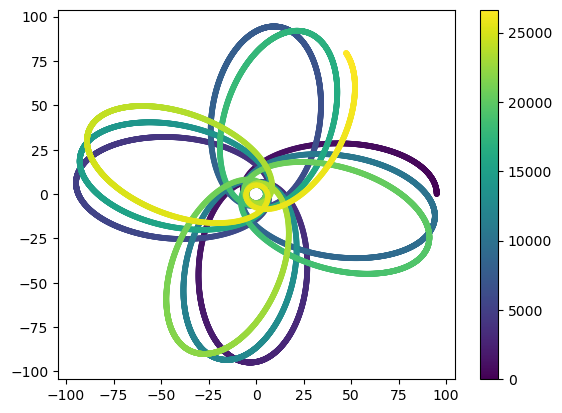

In [404]:
color = sol['t']
plt.scatter(sol['y'][0], sol['y'][1],c=color,s=10)
plt.colorbar()